In [100]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [101]:
df = pd.read_csv("Bradford_Weather_Data.csv")

In [102]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18044 entries, 0 to 18043
Data columns (total 38 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           18044 non-null  object 
 1   Time           18044 non-null  object 
 2   Temp_Out       18044 non-null  object 
 3   Hi_Temp        18044 non-null  object 
 4   Low_Temp       18044 non-null  object 
 5   Out_Hum        18044 non-null  object 
 6   Dew_Pt         18044 non-null  object 
 7   Wind_Speed     18044 non-null  int64  
 8   Wind_Dir       18044 non-null  object 
 9   Wind_Run       18044 non-null  int64  
 10  Hi_Speed       18044 non-null  int64  
 11  Hi_Dir         18044 non-null  object 
 12  Wind_Chill     18044 non-null  object 
 13  Heat_Index     18044 non-null  object 
 14  THW_Index      18044 non-null  object 
 15  THSW_Index     18044 non-null  object 
 16  Bar            18044 non-null  float64
 17  Rain           18044 non-null  float64
 18  Rain_R

In [103]:
df.head()

,Date,Time,Temp_Out,Hi_Temp,Low_Temp,Out_Hum,Dew_Pt,Wind_Speed,Wind_Dir,Wind_Run,...,In_Hum,In_Dew,In_Heat,In_EMC,InAir_Density,ET,Wind_Samp,Wind_Tx,ISS_Recept,Arc_Int
0,13/11/2024,16:00,10.1,10.1,10.1,82,7.1,0,---,0,...,42,8.6,21.2,8.01,1.2070,0,0,1,0,30
1,13/11/2024,16:30,9.7,10.1,9.7,83,7,0,---,0,...,41,8.7,21.8,7.84,1.2048,0,0,4,0,30
2,13/11/2024,17:00,9.6,9.7,9.5,85,7.2,0,---,0,...,42,8.9,21.7,8.00,1.2052,0,0,4,0,30
3,13/11/2024,17:30,9.8,9.8,9.6,85,7.4,0,---,0,...,43,9.0,21.3,8.17,1.2060,0,0,4,0,30
4,13/11/2024,18:00,10.1,10.1,9.8,85,7.7,0,---,0,...,43,9.2,21.7,8.15,1.2047,0,0,4,0,30


In [104]:
print(df.columns)

Index(['Date', 'Time', 'Temp_Out', 'Hi_Temp', 'Low_Temp', 'Out_Hum', 'Dew_Pt',
       'Wind_Speed', 'Wind_Dir', 'Wind_Run', 'Hi_Speed', 'Hi_Dir',
       'Wind_Chill', 'Heat_Index', 'THW_Index', 'THSW_Index', 'Bar  ', 'Rain',
       'Rain_Rate', 'Solar_Rad', 'Solar_Energy', 'Hi Solar_Rad', 'UV_Index',
       'UV_Dose', 'Hi_UV', 'Heat_D-D', 'Cool_D-D', 'In_Temp', 'In_Hum',
       'In_Dew', 'In_Heat', 'In_EMC', 'InAir_Density', 'ET ', 'Wind_Samp',
       'Wind_Tx', 'ISS_Recept', 'Arc_Int'],
      dtype='object')


In [105]:

df["DateTime"] = pd.to_datetime(
    df["Date"].astype(str) + " " + df["Time"].astype(str),
    dayfirst=True,
    format="%d/%m/%Y %H:%M",
    errors="coerce"
)

df.set_index("DateTime", inplace=True)

# Verify
print("Invalid timestamps:", df.index.isna().sum())
print("Index type:", type(df.index))
print("Date range:", df.index.min(), "to", df.index.max())

Invalid timestamps: 0
Index type: <class 'pandas.core.indexes.datetimes.DatetimeIndex'>
Date range: 2024-11-13 16:00:00 to 2025-11-24 14:30:00


In [106]:
daily_temp.describe()

count    376.000000
mean      10.543218
std        5.251602
min       -1.829167
25%        6.536458
50%       10.589583
75%       14.460792
max       23.558333
Name: Temp_Out, dtype: float64

In [107]:
df["Temp_Out"].head(10)


DateTime
2024-11-13 16:00:00    10.1
2024-11-13 16:30:00     9.7
2024-11-13 17:00:00     9.6
2024-11-13 17:30:00     9.8
2024-11-13 18:00:00    10.1
2024-11-13 18:30:00    10.2
2024-11-13 19:00:00    10.3
2024-11-13 19:30:00      10
2024-11-13 20:00:00    10.5
2024-11-13 20:30:00    10.4
Name: Temp_Out, dtype: object

In [108]:
cols = [
    "Temp_Out", "Out_Hum", "Dew_Pt",
    "Wind_Speed", "Hi_Speed", "Rain"
]

for c in cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# Drop rows with no temperature
df = df.dropna(subset=["Temp_Out"])

In [109]:
df["Temp_Out"] = pd.to_numeric(df["Temp_Out"], errors="coerce")


In [110]:
df["Temp_Out"].dtype

dtype('float64')

In [111]:
daily_temp = df["Temp_Out"].resample("D").mean()
daily_hum = df["Out_Hum"].resample("D").mean()
daily_wind = df["Wind_Speed"].resample("D").mean()
daily_rain = df["Rain"].resample("D").sum()
daily_hi_temp = df['Hi_Temp'].resample('D').max()  
daily_low_temp = df['Low_Temp'].resample('D').min()
daily_temp.head()



DateTime
2024-11-13    10.306250
2024-11-14     9.418750
2024-11-15     9.085417
2024-11-16     9.362500
2024-11-17     4.760417
Freq: D, Name: Temp_Out, dtype: float64

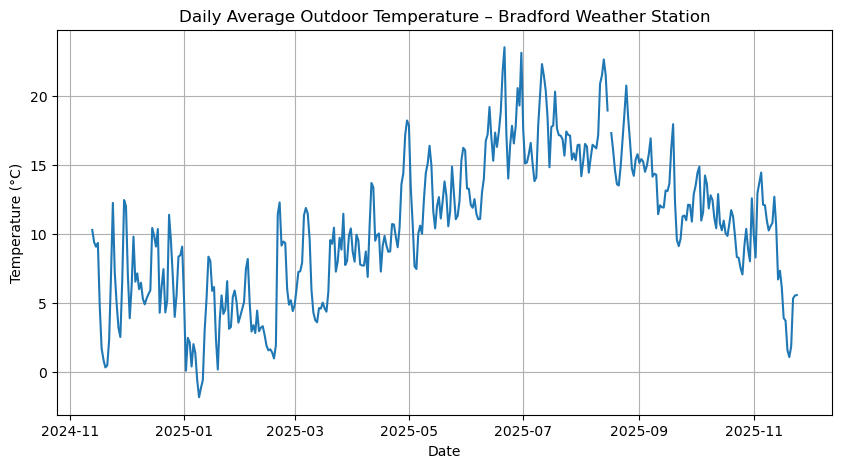

In [112]:
plt.figure(figsize=(10, 5))
plt.plot(daily_temp)
plt.title("Daily Average Outdoor Temperature – Bradford Weather Station")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.grid(True)
plt.show()

Distribution Analysis (data quality & variability)

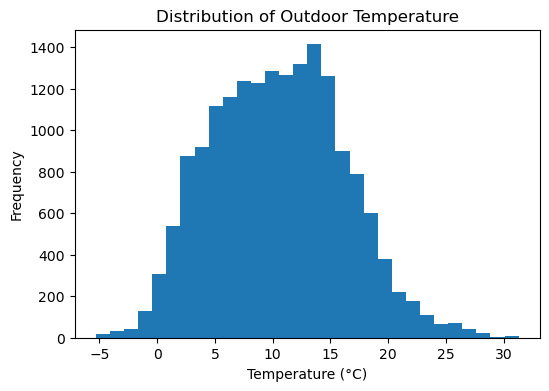

In [113]:
plt.figure(figsize=(6,4))
plt.hist(df["Temp_Out"], bins=30)
plt.title("Distribution of Outdoor Temperature")
plt.xlabel("Temperature (°C)")
plt.ylabel("Frequency")
plt.show()

Correlational Analysis—Wind vs. Temperature

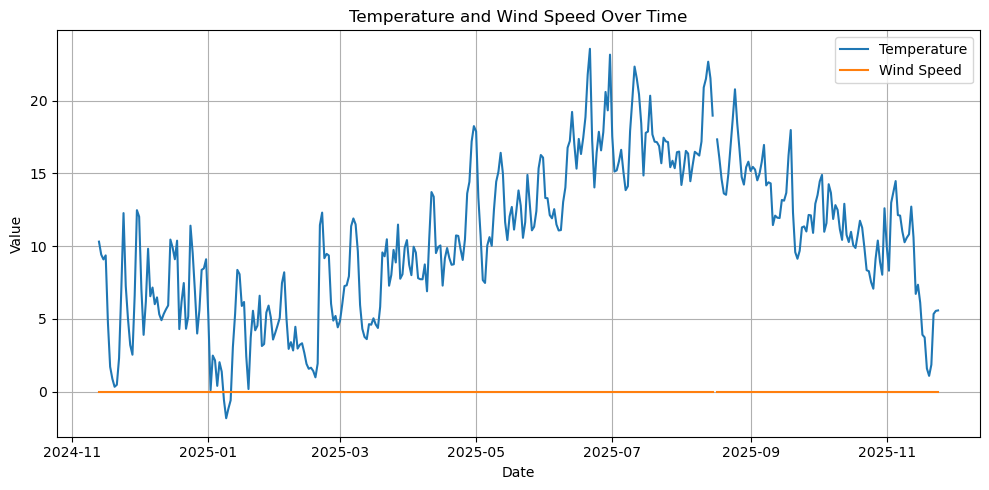

In [114]:
plt.figure(figsize=(10, 5))

plt.plot(daily_temp.index, daily_temp.values, label="Temperature")
plt.plot(daily_wind.index, daily_wind.values, label="Wind Speed")

plt.title("Temperature and Wind Speed Over Time")
plt.xlabel("Date")
plt.ylabel("Value")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [115]:
corr_df = pd.concat([daily_temp, daily_wind], axis=1)
corr_df.columns = ["Temperature", "Wind_Speed"]
corr_df = corr_df.dropna()

In [116]:
corr_value = corr_df["Temperature"].corr(corr_df["Wind_Speed"])

C:\Users\USER\anaconda3\Lib\site-packages\numpy\lib\_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Users\USER\anaconda3\Lib\site-packages\numpy\lib\_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


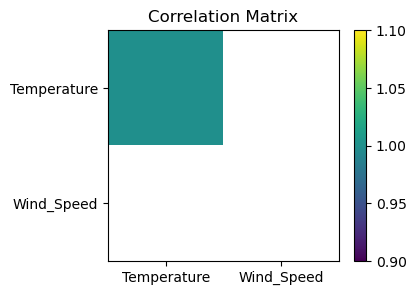

In [117]:
corr = corr_df.corr()

plt.figure(figsize=(4,3))
plt.imshow(corr)
plt.colorbar()
plt.xticks([0,1], corr.columns)
plt.yticks([0,1], corr.columns)
plt.title("Correlation Matrix")
plt.show()

Monthly Climate Distribution

C:\Users\USER\AppData\Local\Temp\ipykernel_2248\651521023.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_temp = daily_temp.resample("M").mean()


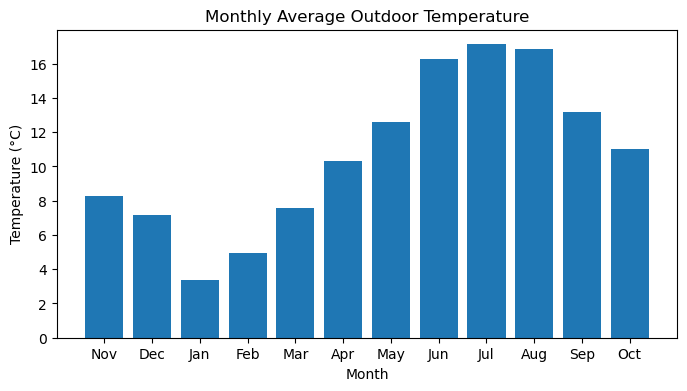

In [118]:
monthly_temp = daily_temp.resample("M").mean()

plt.figure(figsize=(8,4))
plt.bar(monthly_temp.index.strftime("%b"), monthly_temp)
plt.title("Monthly Average Outdoor Temperature")
plt.xlabel("Month")
plt.ylabel("Temperature (°C)")
plt.show()

Extreme Weather Events

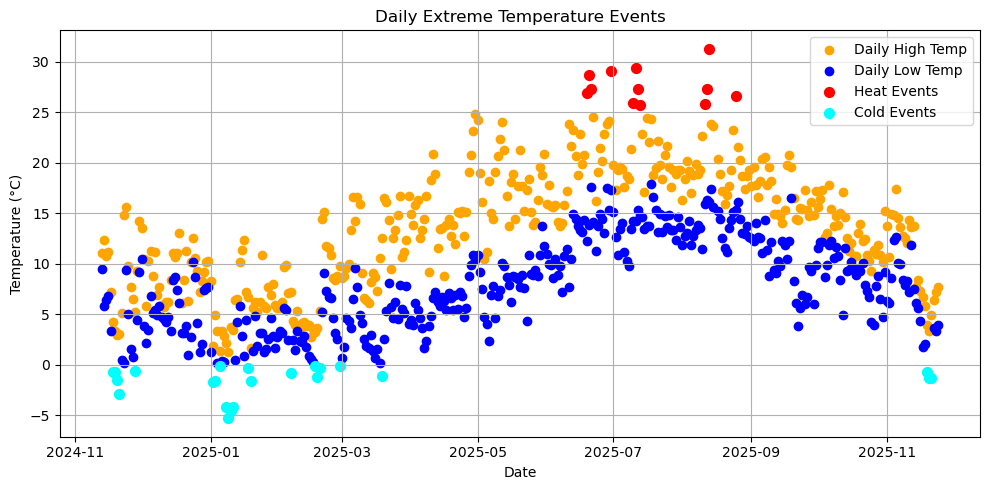

In [129]:
df['Hi_Temp'] = pd.to_numeric(df['Hi_Temp'], errors='coerce')
df['Low_Temp'] = pd.to_numeric(df['Low_Temp'], errors='coerce')

daily_hi_temp = df['Hi_Temp'].resample('D').max()
daily_low_temp = df['Low_Temp'].resample('D').min()

hot_days = daily_hi_temp[daily_hi_temp > 25]    # Heat events
cold_days = daily_low_temp[daily_low_temp < 0]  # Cold events

plt.figure(figsize=(10, 5))

plt.scatter(daily_hi_temp.index, daily_hi_temp.values, label='Daily High Temp', color='orange')
plt.scatter(daily_low_temp.index, daily_low_temp.values, label='Daily Low Temp', color='blue')

plt.scatter(hot_days.index, hot_days.values, label='Heat Events', color='red', s=50)
plt.scatter(cold_days.index, cold_days.values, label='Cold Events', color='cyan', s=50)

plt.title("Daily Extreme Temperature Events")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



Rainfall Events

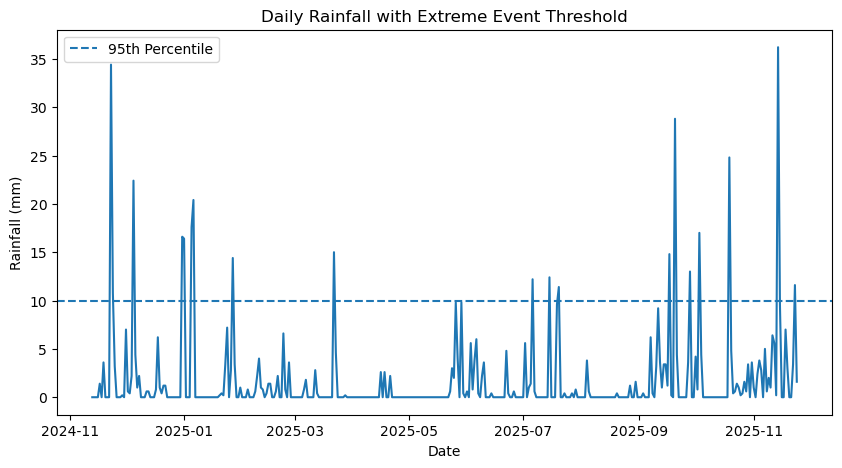

In [120]:
threshold = daily_rain.quantile(0.95)

plt.figure(figsize=(10,5))
plt.plot(daily_rain)
plt.axhline(threshold, linestyle="--", label="95th Percentile")
plt.legend()
plt.title("Daily Rainfall with Extreme Event Threshold")
plt.xlabel("Date")
plt.ylabel("Rainfall (mm)")
plt.show()


Correlational Analysis (multivariate analysis)

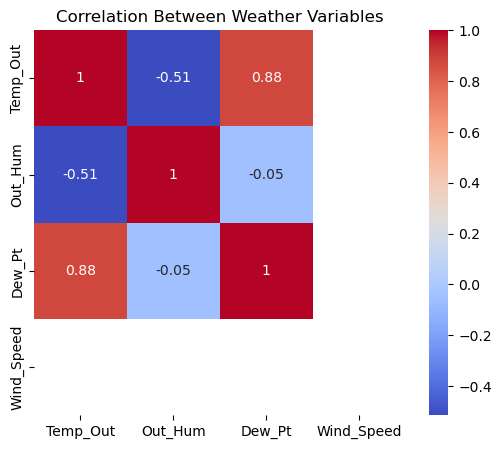

In [121]:
corr_df = df[["Temp_Out", "Out_Hum", "Dew_Pt", "Wind_Speed"]].dropna()
corr = corr_df.corr()

plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Between Weather Variables")
plt.show()

Seasonality Analysis

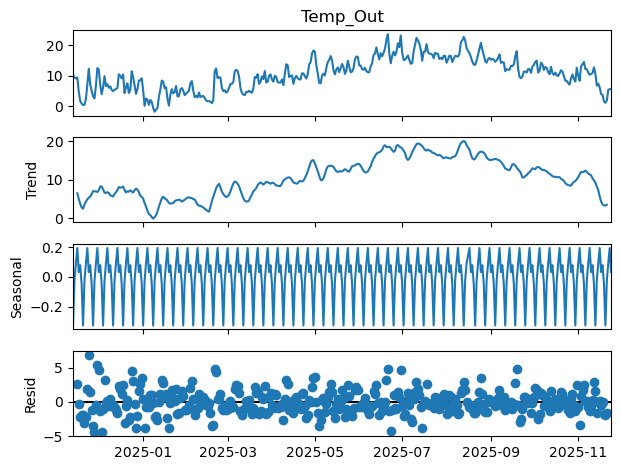

In [122]:
daily_temp_clean = daily_temp.dropna()

decomp = seasonal_decompose(
    daily_temp_clean,
    model="additive",
    period=7
)

decomp.plot()
plt.show()

